# EDA(cleaned_gurgaon_v2.csv)
    1) Univariate Analysis
    2) Multivariate Analysis

    here in this notebook i will perform 'Univariate Anlaysis'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\capstone_project_dscience\\real_estate_project\\dataset\\cleaned_gurgaon_v2.csv')

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df.shape

(3807, 30)

In [4]:
df = df.sample(df.shape[0])

In [5]:
df.duplicated().sum()

np.int64(131)

    there are 131 duplicate values, so let's first remove it

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 3676 entries, 3437 to 3146
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3676 non-null   str    
 1   sector               3676 non-null   str    
 2   society              3238 non-null   str    
 3   price                3675 non-null   float64
 4   price_per_sqft       3675 non-null   float64
 5   area                 3675 non-null   float64
 6   super_built_up_area  1888 non-null   float64
 7   built_up_area        2870 non-null   float64
 8   carpet_area          1888 non-null   float64
 9   bedRoom              3676 non-null   float64
 10  bathroom             3676 non-null   float64
 11  balcony              3676 non-null   str    
 12  floorNum             3658 non-null   float64
 13  agePossession        3675 non-null   str    
 14  store room           3676 non-null   int64  
 15  servant room         3676 non-null   int64  
 16  p

 **property_type**

In [8]:
df['property_type'].value_counts()

property_type
flat     2889
house     787
Name: count, dtype: int64

<Axes: xlabel='property_type', ylabel='count'>

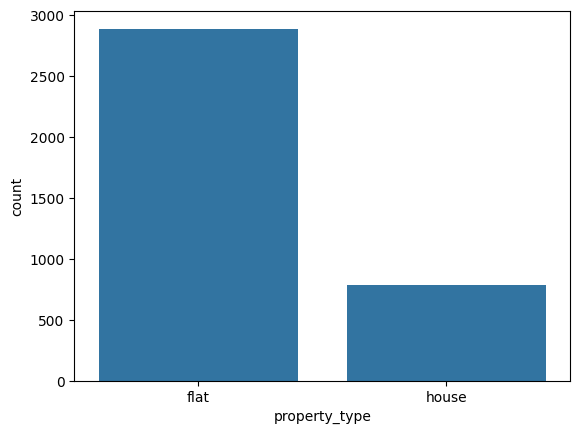

In [9]:
sns.barplot(df['property_type'].value_counts())

**sector**

In [10]:
df['sector'].value_counts()

sector
sohna                      158
sector 37                  119
sector 85                  111
sector 102                 107
sector 70                  104
sector 92                   99
sector 69                   94
sector 90                   88
sector 65                   87
sector 81                   87
sector 109                  81
sector 1                    80
sector 79                   76
sector 104                  74
sector 33                   74
sector 67                   70
sector 83                   68
sector 89                   66
sector 86                   65
sector 95                   62
sector 50                   62
sector 107                  60
sector 82                   60
sector 108                  59
sector 43                   58
sector 48                   55
sector 56                   55
sector 49                   49
sector 84                   49
sector 26                   48
sector 61                   46
sector 113                  46
s

In [11]:
df[df['sector'] == 'new']

,property_type,sector,society,price,price_per_sqft,area,super_built_up_area,built_up_area,carpet_area,bedRoom,bathroom,balcony,floorNum,agePossession,store room,servant room,puja room,study room,others,East,North,North-East,North-West,South,South-East,South-West,Unknown,West,furnish_type,luxury_score
2887,flat,new,dlf,4.00,11428.0,3500.18,NaN,NaN,3500.0,4.0,4.0,2,4.0,under construction,0,1,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2,313.0
3771,flat,new,sare homes,0.85,4786.0,1776.01,1776.0,1776.0,NaN,4.0,4.0,3,3.0,moderately old,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,NaN
3708,flat,new,green court,0.38,5507.0,690.03,NaN,NaN,690.0,2.0,2.0,1,7.0,unknown,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,97.0
3619,flat,new,takshila heights sector c,0.67,5583.0,1200.07,1200.0,1200.0,NaN,2.0,2.0,2,3.0,relatively new,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,104.0


    replace sector of index:
    2887 -> sector 42
    3771 -> sector 49
    3619 -> sector 37
    3708 -> sector 90

In [12]:
df.loc[2887,'sector'] = 'sector 42'
df.loc[3771,'sector'] = 'sector 49'
df.loc[3619,'sector'] = 'sector 37'
df.loc[3708,'sector'] = 'sector 90'

    here as there are so many sectors, i will plot only the top 10, to avoid congestion.

<Axes: xlabel='sector'>

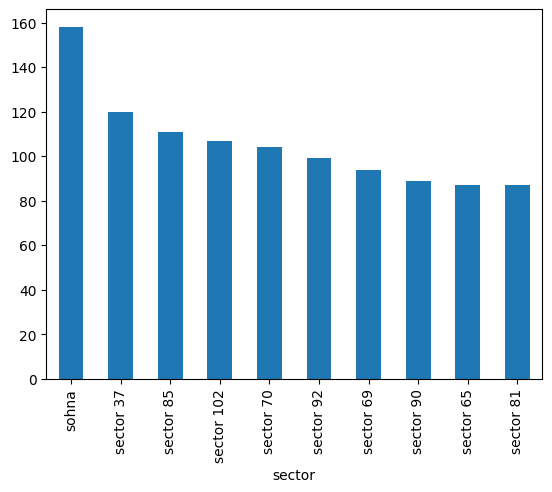

In [13]:
df['sector'].value_counts()[:10].plot(kind='bar')

    now lets make frequency bins. so for this i have to make bins.
        1) 'very high(>100)' : if sector_count > 100
        2) 'high' : if 60<sector_count<100
        3) 'moderate' : if 20<sector_count<60
        4) 'low' : if 5<sector_count<20
        5) 'very low' : if sector_count <5

In [14]:
sector_count = df['sector'].value_counts()

In [15]:
frequency_bins = {
    'very high(>100)' : (sector_count > 100).sum(),
    'high(50-100)' : ((sector_count > 50) & (sector_count <= 100)).sum(),
    'medium(10-50)' : ((sector_count > 10) & (sector_count <= 50)).sum(),
    'low(1-10)' : ((sector_count > 1) & (sector_count <= 10)).sum(),
    'very low(<=1)' : (sector_count <= 1).sum()
}

frequency_bins

{'very high(>100)': np.int64(5),
 'high(50-100)': np.int64(22),
 'medium(10-50)': np.int64(50),
 'low(1-10)': np.int64(25),
 'very low(<=1)': np.int64(1)}

In [16]:
df['sector'].isnull().sum()

np.int64(0)

In [17]:
df['sector'].unique().shape

(103,)

    Observations:
    1) there are a total of 103 unique sectors in the dataset
    2)  frequency distribution:
        'very high(>100)': 5 sectors have more than 100 frequency,
        'high(50-100)': 22 sectors have more than 50 and less than 100 frequency,
        'medium(10-50)': 50 sectors have more than 10 and less than 50 frequency,
        'low(1-10)': 26 sectors have more than 1 and less than 10 frequency,
        'very low(<=1)': 0 sectors have more than or equal to 1 frequency
    

**society**

In [18]:
df['society'].value_counts()

society
tulip violet.                                     73
ss the leaf.                                      72
shapoorji pallonji joyville gurugram.             38
dlf new town heights .                            38
smart world orchard                               37
smart world gems                                  37
signature global park.                            35
shree vardhman victoria.                          34
emaar mgf emerald floors premier.                 32
godrej nature plus                                32
paras dews                                        32
dlf the ultima.                                   31
dlf regal gardens.                                30
la vida by tata housing                           30
international city by sobha phase                 29
shree vardhman flora.                             29
mm woodshire.                                     29
signature global solera.                          27
bptp terra.                           

<Axes: xlabel='society'>

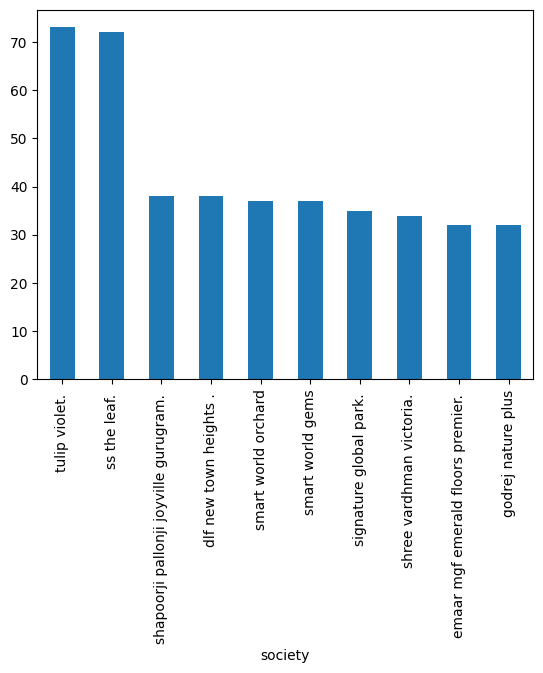

In [19]:
df['society'].value_counts().head(10).plot(kind='bar')

In [28]:
((df['society'].value_counts().cumsum()/df['society'].value_counts().sum())*100).head(75)

society
tulip violet.                              2.254478
ss the leaf.                               4.478073
shapoorji pallonji joyville gurugram.      5.651637
dlf new town heights .                     6.825201
smart world orchard                        7.967881
smart world gems                           9.110562
signature global park.                    10.191476
shree vardhman victoria.                  11.241507
emaar mgf emerald floors premier.         12.229771
godrej nature plus                        13.218036
paras dews                                14.206300
dlf the ultima.                           15.163681
dlf regal gardens.                        16.090179
la vida by tata housing                   17.016677
international city by sobha phase         17.912292
shree vardhman flora.                     18.807906
mm woodshire.                             19.703521
signature global solera.                  20.537369
bptp terra.                               21.309450
expe

    1)from here as we can see that 50 percent of the value counts are covered by top 75 socities
    2)most frequent socities are 'tulip violet' and 'ss the leaf'

**price**

In [29]:
df['price'].value_counts()

price
1.2500     82
1.2000     67
1.5000     64
1.1000     63
1.4000     62
0.9000     61
1.3000     60
2.0000     54
0.9500     51
1.7500     49
1.6000     49
1.3500     47
1.0000     47
1.7000     44
0.7500     44
0.8000     42
0.5000     42
1.6500     42
1.9000     41
1.5500     41
1.8000     41
0.8500     37
1.1500     36
2.5000     36
1.4500     34
2.2000     33
0.6000     32
3.5000     32
0.4000     31
2.1000     31
0.4500     31
0.7000     30
1.0500     28
0.6500     27
1.8500     25
2.2500     25
2.3500     24
3.0000     23
6.5000     22
0.3500     22
0.5500     21
5.5000     21
2.3000     20
5.0000     20
2.4000     20
4.0000     19
3.2500     18
6.0000     18
3.4000     17
2.6000     17
2.6500     16
2.8000     16
0.3800     15
0.8200     15
0.3000     15
1.3800     15
2.1500     15
4.5000     15
0.9200     15
1.9500     15
2.4500     15
7.0000     14
8.5000     14
2.7000     14
4.2500     14
0.4200     14
0.3200     14
8.0000     14
0.7800     13
6.7500     13
2.7500     13


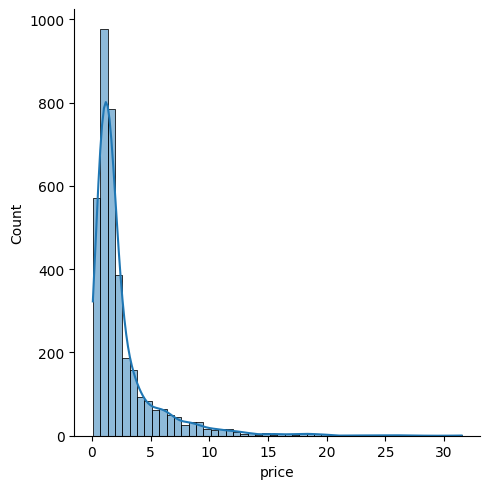

In [34]:
sns.displot(df['price'], bins=50, kde=True)